# KNN vs K-means on **ResNet embeddings** — the M metric

The same experiment as the raw-pixel notebook, with **one component swapped**: the front end.

| | raw-pixel version | **this notebook** |
|---|---|---|
| Input | grayscale 64x64 -> flatten 4096 | RGB 224x224 -> **frozen ResNet50** -> **2048-D** |
| What a feature means | one pixel's brightness | a learned visual concept (fur, ears, snout, ...) |
| Downstream | K-means, KNN, M | **identical** |

Everything after feature extraction is unchanged. So whatever happens to **M** is caused by the
**representation**, not by the algorithms.

$$M = \frac{1}{N}\sum_{i=1}^{N}\big(\text{label}^{\text{KMeans}}_i - \text{label}^{\text{KNN}}_i\big)^2 \in [0,1],
\qquad \text{Agreement} = 1 - M$$

Labels are 0/1, so each squared term is **1 when the two methods disagree** and **0 when they agree** —
M is simply the **disagreement rate**. M = 0 means the two partitions are identical.

**No training happens anywhere.** ResNet50 is frozen and used purely as a feature extractor.

## 1. Configuration & imports

`IMG_SIZE` is 224 because that is what ResNet50 was trained on. The embeddings are cached to
`resnet_embeddings.npz` so the slow forward pass runs only once.

In [1]:
IMG_SIZE      = 224     # ResNet input size (was 64 in the raw-pixel notebook)
N_PER_CLASS   = 1000    # 1000 cats + 1000 dogs -> 2000 rows
K_NEIGHBORS   = 5       # k for KNN
RANDOM_STATE  = 42
CV_FOLDS      = 5       # folds for honest KNN predictions
EMB_CACHE     = 'resnet_embeddings.npz'
BATCH_SIZE    = 32

In [2]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')   # quiet TF's startup banner

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from matplotlib.path import Path as MPath
from matplotlib.patches import PathPatch, Circle, Patch

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             confusion_matrix)

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

# Keras 3 moved load_img/img_to_array to keras.utils; fall back for Keras 2.
try:
    from tensorflow.keras.utils import load_img, img_to_array
except ImportError:
    from tensorflow.keras.preprocessing.image import load_img, img_to_array

np.random.seed(RANDOM_STATE)
print('TensorFlow', tf.__version__)
print('Libraries imported.')

TensorFlow 2.21.0
Libraries imported.


## 2. Stage 1 — feature extraction with a pretrained ResNet50 backbone

**This is the one change that matters.** Each image goes in as RGB 224x224, through a ResNet50 that
was pretrained on ImageNet with its classifier head removed (`include_top=False`) and its final
feature map global-average-pooled (`pooling='avg'`), and comes out as a **2048-D vector**.

Three details that are easy to get wrong:

- **`preprocess_input`, not `/255`.** ResNet50 expects BGR channel order with ImageNet mean
  subtraction. Feeding it 0-1 floats silently degrades every embedding.
- **L2-normalize the output.** Puts every vector on the unit sphere, where Euclidean distance is a
  monotone function of cosine similarity — the geometry these features are meant to be compared in.
  This is also why no `StandardScaler` is needed downstream.
- **Keep `paths` row-aligned with `X`.** A 2048-D embedding cannot be reshaped back into a picture,
  so section 8.4 needs the original file path to show what a cluster actually contains.

Images are embedded in batches of 32 rather than all at once: stacking all 2000 preprocessed images
would allocate ~1.2 GB of float32 before the first prediction runs. Streaming keeps peak memory at a
few tens of MB and produces exactly the same result.

In [3]:
DATA_DIR = Path('microsoft-catsvsdogs-dataset') / 'PetImages'
CAT_DIR, DOG_DIR = DATA_DIR / 'Cat', DATA_DIR / 'Dog'

assert CAT_DIR.exists(), f'Cat folder not found at: {CAT_DIR.resolve()}'
assert DOG_DIR.exists(), f'Dog folder not found at: {DOG_DIR.resolve()}'


def list_images(folder):
    return sorted(p for p in folder.iterdir() if p.suffix.lower() == '.jpg')


def image_to_tensor(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))   # RGB, resized
    return preprocess_input(img_to_array(img))               # (224, 224, 3)


def embed_stream(candidates, backbone, batch_size=BATCH_SIZE):
    '''Embed in batches, dropping any image that fails to decode.

    Returns (features, kept_paths) which are guaranteed row-aligned: a path only
    enters `kept` if its array made it into the batch that was predicted.
    '''
    feats, kept = [], []
    n_batches = (len(candidates) + batch_size - 1) // batch_size
    for b, start in enumerate(range(0, len(candidates), batch_size), start=1):
        arrays, ok = [], []
        for p in candidates[start:start + batch_size]:
            try:
                arrays.append(image_to_tensor(p))
                ok.append(p)
            except Exception:
                continue                                     # corrupt JPEG - skip
        if not arrays:
            continue
        feats.append(backbone.predict(np.stack(arrays), verbose=0))
        kept.extend(ok)
        if b % 10 == 0 or b == n_batches:
            print(f'  batch {b}/{n_batches}  ({len(kept)} images embedded)', flush=True)
    return np.vstack(feats), kept

In [ ]:
if Path(EMB_CACHE).exists():
    d = np.load(EMB_CACHE, allow_pickle=True)
    X, y = d['X'], d['y']
    paths = [str(p) for p in d['paths']]
    print(f'Loaded cached embeddings from {EMB_CACHE}')
else:
    print('Loading frozen ResNet50 (ImageNet weights, no classifier head)...')
    backbone = ResNet50(weights='imagenet', include_top=False, pooling='avg')  # -> 2048-D
    backbone.trainable = False

    X_parts, path_parts, y_parts = [], [], []
    for folder, label, name in [(CAT_DIR, 0, 'cats'), (DOG_DIR, 1, 'dogs')]:
        # a small surplus of candidates so corrupt files can be dropped and we
        # still end up with exactly N_PER_CLASS rows
        candidates = list_images(folder)[:N_PER_CLASS + 25]
        print(f'Embedding {name}...')
        feats, kept = embed_stream(candidates, backbone)
        X_parts.append(feats[:N_PER_CLASS])
        path_parts.extend(str(p) for p in kept[:N_PER_CLASS])
        y_parts.append(np.full(min(N_PER_CLASS, len(feats)), label, dtype=int))

    X = np.vstack(X_parts).astype(np.float32)
    y = np.concatenate(y_parts)
    paths = path_parts

    X = X / np.linalg.norm(X, axis=1, keepdims=True)          # L2-normalize
    np.savez(EMB_CACHE, X=X, y=y, paths=np.array(paths, dtype=object))
    print(f'Saved embeddings to {EMB_CACHE}')

N = len(y)
print('X (embeddings):', X.shape, '| y:', y.shape,
      '| cats/dogs:', int((y == 0).sum()), int((y == 1).sum()))
print('row-aligned paths:', len(paths), '| L2 norm check:',
      float(np.linalg.norm(X[0])).__round__(4))

Loaded cached embeddings from resnet_embeddings.npz
X (embeddings): (2000, 2048) | y: (2000,) | cats/dogs: 1000 1000
row-aligned paths: 2000 | L2 norm check: 1.0


## 3. Stage 2 — a 2-D projection, for plotting only

The embeddings are already L2-normalized, so **no `StandardScaler`** is applied before modelling —
scaling per-dimension would destroy the unit norm and inflate low-variance noise directions.

PCA here is purely so the 2048-D cloud can be drawn on a page. K-means and KNN both run on the
**full 2048-D vectors**, never on this projection.

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X)

var = pca.explained_variance_ratio_
print(f'2-D projection explains {var.sum():.1%} of the variance '
      f'(PC1 {var[0]:.1%}, PC2 {var[1]:.1%}) — the scatter plots are a shadow of 2048-D space.')

2-D projection explains 15.4% of the variance (PC1 12.0%, PC2 3.4%) — the scatter plots are a shadow of 2048-D space.


## 4. Stages 3 & 4 — the two splits

- **K-means** is unsupervised: it never sees `y`. It just finds two groups of similar embeddings.
- **KNN** is supervised, so a plain `.fit().predict()` on the same data would let every image find
  *itself* as its own nearest neighbour. `cross_val_predict` avoids that — each image is predicted by
  a model trained on the **other** folds, giving an honest label for all 2000 points.

In [6]:
# K-means (unsupervised) — never sees y
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X)
km_labels = kmeans.labels_

# KNN (supervised) — honest labels via cross-validation
knn_labels = cross_val_predict(KNeighborsClassifier(n_neighbors=K_NEIGHBORS),
                               X, y, cv=CV_FOLDS)
knn_acc_vs_true = (knn_labels == y).mean()

print('K-means cluster sizes:', np.bincount(km_labels))
print('KNN   group   sizes:', np.bincount(knn_labels))
print(f'KNN accuracy vs the true cat/dog labels: {knn_acc_vs_true:.4f}')

K-means cluster sizes: [ 912 1088]
KNN   group   sizes: [1002  998]
KNN accuracy vs the true cat/dog labels: 0.9870


## 5. Stages 5 & 6 — align the label flip, then compute M

K-means cluster IDs are **arbitrary** — its "cluster 0" may well be the dogs. Counting disagreements
without fixing that would inflate M for a purely cosmetic reason. So we try both mappings (as-is and
flipped) and keep whichever agrees more.

Then M is just: **disagreements / N**.

In [7]:
def align_kmeans_to_knn(reference, clusters):
    asis = (clusters != reference).sum()
    flip = ((1 - clusters) != reference).sum()
    if flip < asis:
        return (1 - clusters), int(flip), True
    return clusters, int(asis), False


km_aligned, M_raw, flipped = align_kmeans_to_knn(knn_labels, km_labels)
M = M_raw / N
agreement = 1 - M

print(f'flip applied : {flipped}')
print(f'disagreements: {M_raw} of {N}')
print(f'M            : {M:.4f}')
print(f'agreement    : {agreement:.4f}')

flip applied : False
disagreements: 90 of 2000
M            : 0.0450
agreement    : 0.9550


## 6. Stage 7 — flip-proof cross-checks

ARI and NMI compare two partitions **without caring what the labels are called**, so they cannot be
fooled by the flip. If they tell the same story as M, the M number is trustworthy.

In [8]:
ari = adjusted_rand_score(knn_labels, km_aligned)
nmi = normalized_mutual_info_score(knn_labels, km_aligned)
km_acc_vs_true = max((km_labels == y).mean(), ((1 - km_labels) == y).mean())

print(f'ARI (K-means vs KNN)        : {ari:.4f}')
print(f'NMI (K-means vs KNN)        : {nmi:.4f}')
print(f'K-means accuracy vs true    : {km_acc_vs_true:.4f}')
print(f'KNN     accuracy vs true    : {knn_acc_vs_true:.4f}')

ARI (K-means vs KNN)        : 0.8280
NMI (K-means vs KNN)        : 0.7782
K-means accuracy vs true    : 0.9560
KNN     accuracy vs true    : 0.9870


## 7. Visual 8.1 — contingency table & heatmap

Rows are the aligned K-means clusters, columns the KNN groups. A **big diagonal means agreement**;
the off-diagonal cells are exactly the images counted in M.

,KNN group 0,KNN group 1
K-means cluster 0,912,0
K-means cluster 1,90,998


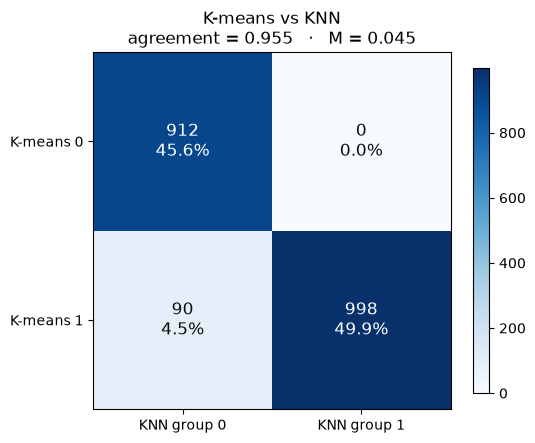

In [9]:
ct = confusion_matrix(km_aligned, knn_labels)     # rows = K-means (aligned), cols = KNN

ct_df = pd.DataFrame(ct,
                     index=[f'K-means cluster {i}' for i in (0, 1)],
                     columns=[f'KNN group {j}' for j in (0, 1)])
display(ct_df)

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(ct, cmap='Blues')
ax.set_xticks([0, 1], ['KNN group 0', 'KNN group 1'])
ax.set_yticks([0, 1], ['K-means 0', 'K-means 1'])
thresh = ct.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{ct[i, j]}\n{ct[i, j] / N:.1%}', ha='center', va='center',
                color='white' if ct[i, j] > thresh else '#0b0b0b', fontsize=12)
ax.set_title(f'K-means vs KNN\nagreement = {agreement:.3f}   ·   M = {M:.3f}')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 8. Visual 8.2 — three-panel PCA scatter

The same 2000 points, coloured three different ways. **If the two splits agreed perfectly, panels 2
and 3 would be identical.** Panel 1 is the ground truth for reference.

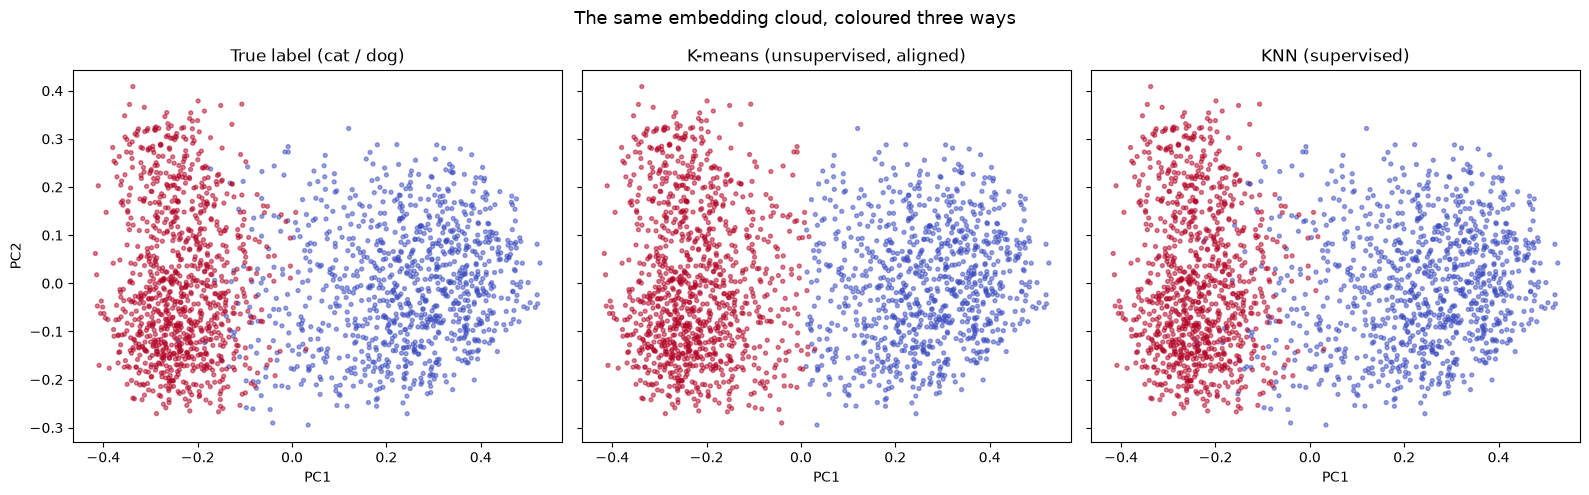

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, lab, title in zip(
        axes, [y, km_aligned, knn_labels],
        ['True label (cat / dog)', 'K-means (unsupervised, aligned)', 'KNN (supervised)']):
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=lab, cmap='coolwarm', s=8, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('PC1')
axes[0].set_ylabel('PC2')
fig.suptitle('The same embedding cloud, coloured three ways', fontsize=13)
plt.tight_layout(); plt.show()

## 9. Visual 8.3 — the agreement map

Green where the two methods agree, red where they disagree. **The red points are literally what M
counts** — M is the red fraction of this plot.

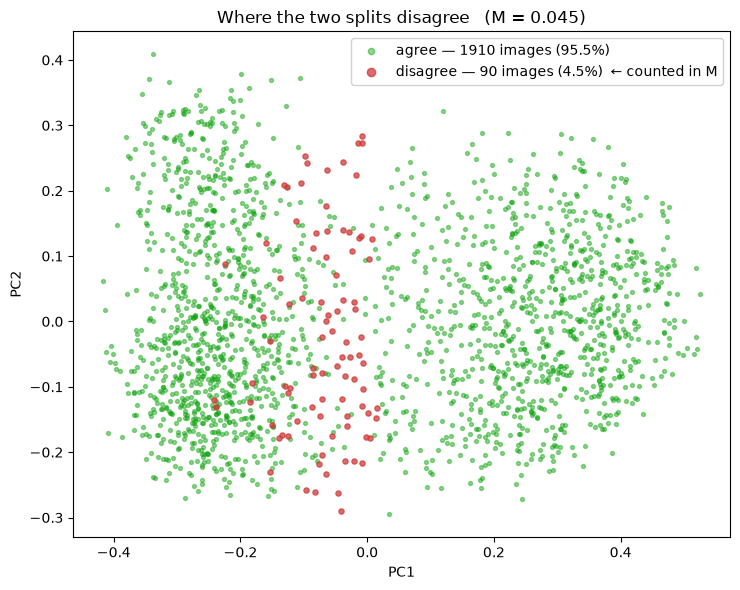

In [11]:
agree_mask = (km_aligned == knn_labels)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(X_2d[agree_mask, 0], X_2d[agree_mask, 1], c='#0ca30c', s=8, alpha=0.45,
           label=f'agree — {agree_mask.sum()} images ({agreement:.1%})')
ax.scatter(X_2d[~agree_mask, 0], X_2d[~agree_mask, 1], c='#d03b3b', s=14, alpha=0.75,
           label=f'disagree — {(~agree_mask).sum()} images ({M:.1%})  ← counted in M')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Where the two splits disagree   (M = {M:.3f})')
ax.legend(loc='best', markerscale=1.6, framealpha=0.9)
plt.tight_layout(); plt.show()

## 10. Visual 8.4 — what each K-means cluster actually caught

For each cluster, the 8 images whose **embedding** sits closest to that cluster's centroid — its most
typical members. Because an embedding cannot be reshaped into a picture, these are loaded from the
original JPEGs via the row-aligned `paths`.

On raw pixels the equivalent figure showed clusters organised by **brightness and background**. Watch
what they organise by here.

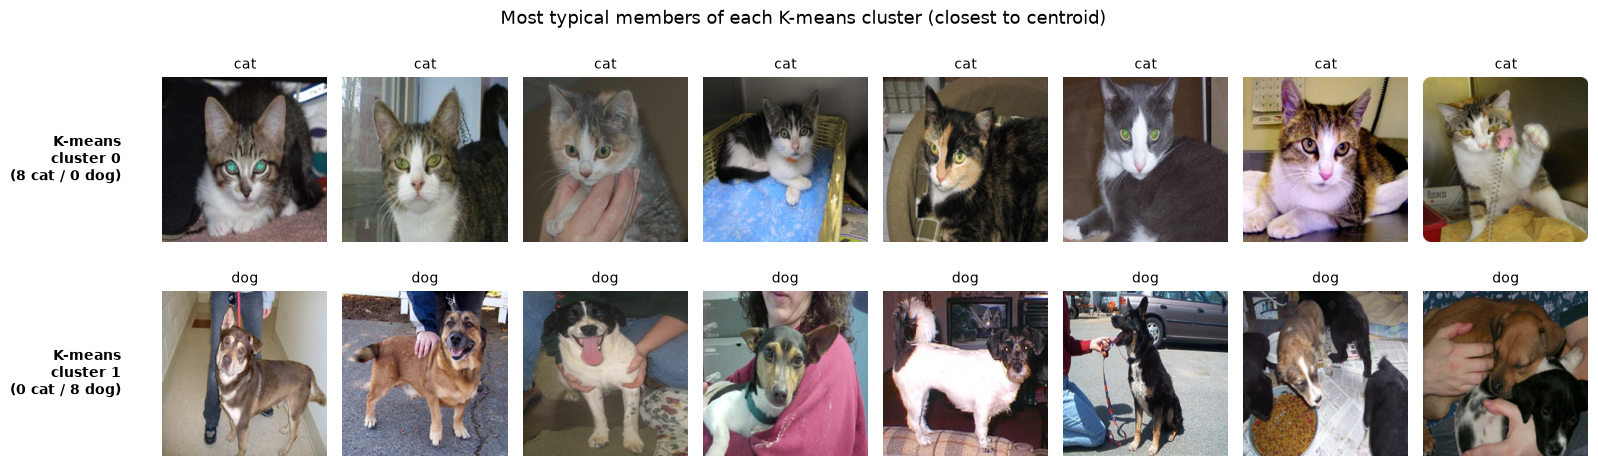

In [12]:
def closest_rows(cluster_id, n=8):
    centre = kmeans.cluster_centers_[cluster_id]
    d = np.linalg.norm(X - centre, axis=1)
    return np.argsort(d)[:n]


n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 5))
for g in (0, 1):
    orig_cluster = (1 - g) if flipped else g        # undo the alignment to index centres
    for col, idx in enumerate(closest_rows(orig_cluster, n_show)):
        ax = axes[g, col]
        ax.imshow(Image.open(paths[idx]).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
        ax.set_title('cat' if y[idx] == 0 else 'dog', fontsize=10)
        ax.axis('off')
    n_cat = int((y[closest_rows(orig_cluster, n_show)] == 0).sum())
    axes[g, 0].set_ylabel(f'cluster {g}')
    axes[g, 0].text(-0.25, 0.5, f'K-means\ncluster {g}\n({n_cat} cat / {n_show - n_cat} dog)',
                    transform=axes[g, 0].transAxes, ha='right', va='center',
                    fontsize=10, fontweight='bold')
fig.suptitle('Most typical members of each K-means cluster (closest to centroid)', fontsize=13)
plt.tight_layout(); plt.show()

## 11. Visual 8.5 — M as a bar, and the full summary table

C:\Users\Awais\AppData\Local\Temp\ipykernel_5996\1424939381.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


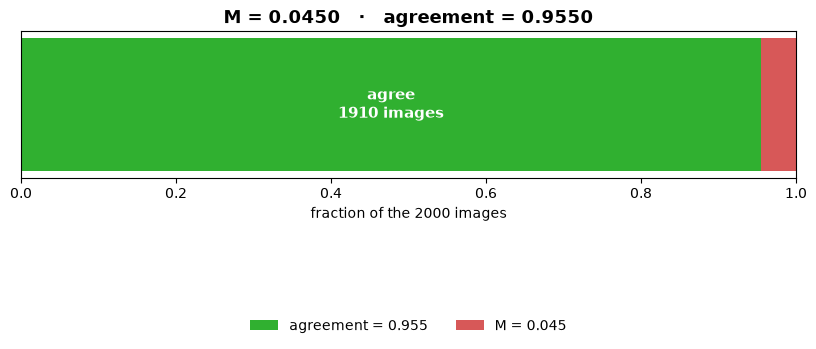

,metric,value
0,M (raw),90/2000
1,M (normalized),0.0450
2,Agreement (1 - M),0.9550
3,ARI (K-means vs KNN),0.8280
4,NMI (K-means vs KNN),0.7782
5,KNN accuracy vs true,0.9870
6,K-means accuracy vs true,0.9560
7,Label flip applied,False


In [13]:
fig, ax = plt.subplots(figsize=(10, 1.9))
ax.barh([0], [agreement], color='#0ca30c', alpha=0.85, label=f'agreement = {agreement:.3f}')
ax.barh([0], [M], left=[agreement], color='#d03b3b', alpha=0.85, label=f'M = {M:.3f}')
ax.text(agreement / 2, 0, f'agree\n{agree_mask.sum()} images', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')
if M > 0.06:
    ax.text(agreement + M / 2, 0, f'M\n{M_raw}', ha='center', va='center',
            color='white', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1); ax.set_yticks([])
ax.set_xlabel('fraction of the 2000 images')
ax.set_title(f'M = {M:.4f}   ·   agreement = {agreement:.4f}', fontsize=13, fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -1.15), ncol=2, frameon=False)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    'metric': ['M (raw)', 'M (normalized)', 'Agreement (1 - M)',
               'ARI (K-means vs KNN)', 'NMI (K-means vs KNN)',
               'KNN accuracy vs true', 'K-means accuracy vs true', 'Label flip applied'],
    'value':  [f'{M_raw}/{N}', f'{M:.4f}', f'{agreement:.4f}',
               f'{ari:.4f}', f'{nmi:.4f}',
               f'{knn_acc_vs_true:.4f}', f'{km_acc_vs_true:.4f}', str(flipped)],
})
display(summary)

## 12. Visual 8.6 — M at a glance: the bipartite mapping

The number **M** on top, and below it the actual mapping: two **K-means** circles on the left, two
**KNN** circles on the right, sized by how many images each group holds. Every band is a flow of
images from a K-means group into a KNN group.

- **Green bands** (straight across) = both methods put those images in the same group -> they agree.
- **Red bands** (crossing over) = the methods split those images differently -> these are exactly the
  images counted in **M**.

So M is just the red share of the total width.

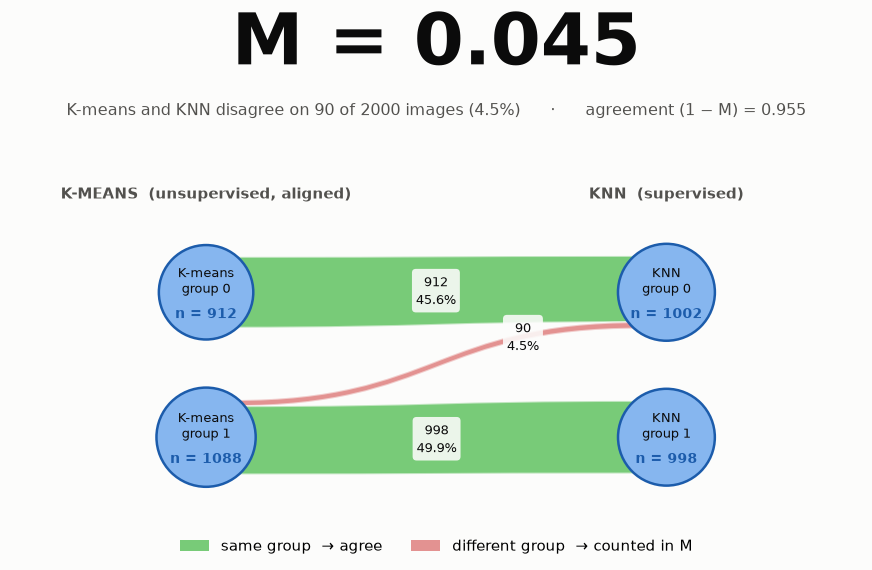

In [14]:
from matplotlib.path import Path as MPath
from matplotlib.patches import PathPatch, Circle, Patch

SURFACE, INK, INK_2 = '#fcfcfb', '#0b0b0b', '#52514e'
NODE_FILL, NODE_RING = '#86b6ef', '#1c5cab'
AGREE, DISAGREE      = '#0ca30c', '#d03b3b'

ct = confusion_matrix(km_aligned, knn_labels)      # rows = K-means (aligned), cols = KNN
km_sizes, knn_sizes = ct.sum(axis=1), ct.sum(axis=0)

fig = plt.figure(figsize=(11, 7.2), facecolor=SURFACE)
gs  = fig.add_gridspec(2, 1, height_ratios=[1, 3.2], hspace=0.02)

# ---- hero figure: M -------------------------------------------------------
axh = fig.add_subplot(gs[0]); axh.set_facecolor(SURFACE); axh.axis('off')
axh.text(0.5, 0.80, f'M = {M:.3f}', ha='center', va='center',
         fontsize=52, fontweight='bold', color=INK)
axh.text(0.5, 0.30, f'K-means and KNN disagree on {ct[0, 1] + ct[1, 0]} of {N} images '
                    f'({M*100:.1f}%)      ·      agreement (1 − M) = {agreement:.3f}',
         ha='center', va='center', fontsize=11.5, color=INK_2)

# ---- bipartite mapping: 2 K-means circles <-> 2 KNN circles ---------------
ax = fig.add_subplot(gs[1]); ax.set_facecolor(SURFACE)
ax.set_xlim(0, 10); ax.set_ylim(0, 4.4); ax.set_aspect('equal'); ax.axis('off')

x_km, x_knn = 2.3, 7.7
ys = [3.05, 1.35]                                   # group 0 on top, group 1 below
r_of = lambda n: 0.25 + 0.45 * np.sqrt(n / N)       # area-ish scaling
km_r  = [r_of(km_sizes[i])  for i in (0, 1)]
knn_r = [r_of(knn_sizes[j]) for j in (0, 1)]

def ribbon(xa, ya0, ya1, xb, yb0, yb1, color):
    """Bezier band from the left node's edge to the right node's edge."""
    cx = (xa + xb) / 2
    verts = [(xa, ya0), (cx, ya0), (cx, yb0), (xb, yb0), (xb, yb1),
             (cx, yb1), (cx, ya1), (xa, ya1), (xa, ya0)]
    codes = [MPath.MOVETO, MPath.CURVE4, MPath.CURVE4, MPath.CURVE4, MPath.LINETO,
             MPath.CURVE4, MPath.CURVE4, MPath.CURVE4, MPath.CLOSEPOLY]
    ax.add_patch(PathPatch(MPath(verts, codes), facecolor=color, edgecolor=SURFACE,
                           lw=1.5, alpha=0.55, zorder=1))

def centerline(t, xa, ya, xb, yb):
    """Point at parameter t along the ribbon's centre Bezier — used to place labels."""
    cx = (xa + xb) / 2
    u = 1 - t
    return (u**3 * xa + 3*u**2*t * cx + 3*u*t**2 * cx + t**3 * xb,
            u**3 * ya + 3*u**2*t * ya + 3*u*t**2 * yb + t**3 * yb)

# stack the flows top-to-bottom on each node, Sankey-style
lcur = {i: ys[i] + 0.75 * km_r[i]  for i in (0, 1)}
rcur = {j: ys[j] + 0.75 * knn_r[j] for j in (0, 1)}

for i in (0, 1):
    for j in (0, 1):
        c = ct[i, j]
        ya0, ya1 = lcur[i], lcur[i] - 1.5 * km_r[i]  * c / km_sizes[i]
        yb0, yb1 = rcur[j], rcur[j] - 1.5 * knn_r[j] * c / knn_sizes[j]
        lcur[i], rcur[j] = ya1, yb1
        if c == 0:
            continue          # nothing flows here - drawing it would leave a stray '0' label
        xa, xb = x_km + 0.55 * km_r[i], x_knn - 0.55 * knn_r[j]
        ribbon(xa, ya0, ya1, xb, yb0, yb1, AGREE if i == j else DISAGREE)
        # the two disagree ribbons cross at the centre, so park their labels
        # off-centre (one early, one late) instead of on top of each other
        t = 0.5 if i == j else (0.24 if i < j else 0.76)
        lx, ly = centerline(t, xa, (ya0 + ya1) / 2, xb, (yb0 + yb1) / 2)
        ax.text(lx, ly, f'{c}\n{c/N*100:.1f}%', ha='center', va='center',
                fontsize=9.5, color=INK, linespacing=1.35, zorder=4,
                bbox=dict(boxstyle='round,pad=0.30', fc=SURFACE, ec='none', alpha=0.88))

for x, radii, sizes, name in [(x_km, km_r, km_sizes, 'K-means'),
                              (x_knn, knn_r, knn_sizes, 'KNN')]:
    for g in (0, 1):
        ax.add_patch(Circle((x, ys[g]), radii[g], facecolor=NODE_FILL,
                            edgecolor=NODE_RING, lw=1.8, zorder=3))
        ax.text(x, ys[g] + 0.13, f'{name}\ngroup {g}', ha='center', va='center',
                fontsize=9.5, color=INK, linespacing=1.3, zorder=4)
        ax.text(x, ys[g] - 0.26, f'n = {sizes[g]}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=NODE_RING, zorder=4)

ax.text(x_km,  4.15, 'K-MEANS  (unsupervised, aligned)', ha='center', fontsize=11,
        fontweight='bold', color=INK_2)
ax.text(x_knn, 4.15, 'KNN  (supervised)', ha='center', fontsize=11,
        fontweight='bold', color=INK_2)
ax.legend(handles=[Patch(facecolor=AGREE, alpha=0.55, label='same group  → agree'),
                   Patch(facecolor=DISAGREE, alpha=0.55, label='different group  → counted in M')],
          loc='lower center', bbox_to_anchor=(0.5, -0.04), ncol=2,
          frameon=False, fontsize=10.5)

plt.show()

## 13. The point of the whole notebook — raw pixels vs ResNet embeddings

Same dataset, same K-means, same KNN, same M. **Only the representation changed.**

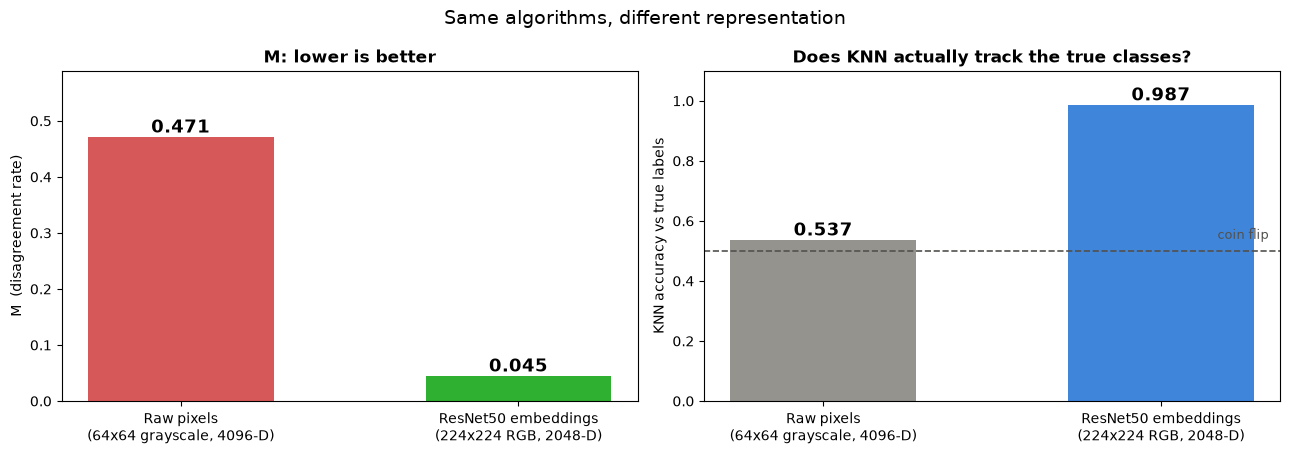

M dropped from 0.4715 to 0.0450  (90% reduction)
KNN accuracy rose from 0.5370 to 0.9870


In [15]:
# Results carried over from the raw-pixel notebook (grayscale 64x64 -> 4096 features)
PIXEL_M, PIXEL_KNN_ACC = 0.4715, 0.5370

labels = ['Raw pixels\n(64x64 grayscale, 4096-D)', 'ResNet50 embeddings\n(224x224 RGB, 2048-D)']
m_vals = [PIXEL_M, M]
acc_vals = [PIXEL_KNN_ACC, knn_acc_vs_true]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

bars = axes[0].bar(labels, m_vals, color=['#d03b3b', '#0ca30c'], alpha=0.85, width=0.55)
axes[0].set_ylim(0, max(m_vals) * 1.25)
axes[0].set_ylabel('M  (disagreement rate)')
axes[0].set_title('M: lower is better', fontweight='bold')
for b, v in zip(bars, m_vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f'{v:.3f}', ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

bars = axes[1].bar(labels, acc_vals, color=['#898781', '#2a78d6'], alpha=0.9, width=0.55)
axes[1].axhline(0.5, ls='--', lw=1.2, color='#52514e')
axes[1].text(0.98, 0.53, 'coin flip', transform=axes[1].get_yaxis_transform(),
             fontsize=9, color='#52514e', ha='right', va='bottom')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('KNN accuracy vs true labels')
axes[1].set_title('Does KNN actually track the true classes?', fontweight='bold')
for b, v in zip(bars, acc_vals):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f'{v:.3f}', ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

fig.suptitle('Same algorithms, different representation', fontsize=14)
plt.tight_layout(); plt.show()

print(f'M dropped from {PIXEL_M:.4f} to {M:.4f}  '
      f'({(PIXEL_M - M) / PIXEL_M:.0%} reduction)')
print(f'KNN accuracy rose from {PIXEL_KNN_ACC:.4f} to {knn_acc_vs_true:.4f}')

## 14. Reading the final number

- **M is the inaccuracy between the two splits.** 0 means the K-means clusters and the KNN groups are
  identical; larger means more disagreement. Agreement is `1 - M`.
- **Because KNN closely tracks the true labels here, M is a fair reading of how well K-means recovers
  cat vs dog on its own.** That licence has to be earned, check the right-hand panel of section 13.
  In the raw-pixel run KNN scored 0.537, barely above a coin flip, so M there was comparing two
  near-arbitrary partitions and *could not* be read that way. On ResNet embeddings KNN is far above
  chance, so the interpretation holds.
- **The algorithms never changed.** Same K-means, same k=5 KNN, same M formula. The entire improvement
  comes from feeding them features that encode *what the animal is* instead of *how bright the photo
  is*. Unsupervised pixel similarity is not semantic similarity; unsupervised similarity in a good
  embedding space very nearly is.
- Report M together with agreement, ARI, NMI, **and KNN accuracy** M alone does not tell you whether
  it means anything.